In [16]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.optimize import curve_fit
from scipy.ndimage import shift as ndi_shift
from uncertainties import ufloat

In [18]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [ ]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

In [20]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

theta_grid_size = 64
R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)

In [21]:
wvft_1_mn = [[2, 2], [0, 4]]
wvft_1_coef = [0.3, 0.5]

wvft_2_mn = [[-1, 3], [0, 4]]
wvft_2_coef = [0.5, 0.5]

wvft_3_mn = [[-1, 3], [-2, 2]]
wvft_3_coef = [0.5, 0.3]

wvft_4_mn = [[-1, 3], [2, 2]]
wvft_4_coef = [0.5, 0.3]

wvft_5_mn = [[-1, 3], [-2, 2], [0, 4]]
wvft_5_coef = [0.5, 0.3, 0.5]

wvft_6_mn = [[-1, 3], [2, 2], [0, 4]]
wvft_6_coef = [0.5, 0.3, 0.5]

aberrations = [
    wvft_1_mn,
    wvft_2_mn,
    wvft_3_mn,
    wvft_4_mn,
    wvft_5_mn,
    wvft_6_mn,
]

coefs = [
    wvft_1_coef,
    wvft_2_coef,
    wvft_3_coef,
    wvft_4_coef,
    wvft_5_coef,
    wvft_6_coef,
]

In [22]:
def eightbit_normalize(img):
    norm_img = (img - np.min(img)) / (np.max(img) - np.min(img))
    return (norm_img * 256).astype(int)

def simulate_img(microscope, L_ffp, grid_ffp, z_level, modes, strengths, bead_radius,
                 x_shift = 0, y_shift = 0, noise = False, background_lam = 0):
    grid = Grid(L_ffp, grid_ffp, x_shift, y_shift, z_level)

    aberration = Aberration(modes, strengths)
    x, y, I = microscope.compute_PSF(grid, aberration)
    _, _, bead = bead_img(grid, [0], [0], [bead_radius])
    convolved_img = psf_convolve(I, bead)
    final_img = eightbit_normalize(convolved_img)
    if noise:
        final_img = add_noise(final_img, m = 1, b = background_lam, seed = 0)
    return x, y, final_img

def add_noise(img, m, b, seed = 0):
    if seed != 0:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()
    return rng.poisson(img * m + b)

In [23]:
def crop_aligned_integer(img1, img2, di, dj):
    """
    Original integer-pixel cropping logic.

    Positive di means img2 is shifted downward relative to img1.
    Positive dj means img2 is shifted rightward relative to img1.
    """
    H, W = img1.shape

    di = int(di)
    dj = int(dj)

    # Rows
    if di >= 0:
        rows1 = slice(0, H - di)
        rows2 = slice(di, H)
    else:
        rows1 = slice(-di, H)
        rows2 = slice(0, H + di)

    # Columns
    if dj >= 0:
        cols1 = slice(0, W - dj)
        cols2 = slice(dj, W)
    else:
        cols1 = slice(-dj, W)
        cols2 = slice(0, W + dj)

    return img1[rows1, cols1], img2[rows2, cols2]


def crop_aligned_subpixel(img1, img2, di, dj, order=1):
    """x
    Align img2 to img1 using a possibly fractional-pixel shift,
    then crop both images to the physically meaningful overlap region.

    Positive di means img2 is shifted downward relative to img1.
    Positive dj means img2 is shifted rightward relative to img1.

    To align img2 back onto img1, we shift img2 by (-di, -dj).
    """

    # Shift img2 back toward img1
    shifted_img2 = ndi_shift(
        img2,
        shift=(-di, -dj),
        order=order,
        mode="constant",
        cval=0.0
    )

    # Shift a mask the same way so we know which pixels are valid
    mask2 = np.ones_like(img2, dtype=float)

    shifted_mask2 = ndi_shift(
        mask2,
        shift=(-di, -dj),
        order=0,
        mode="constant",
        cval=0.0
    )

    overlap = shifted_mask2 > 0.5

    # Convert the overlap mask into a rectangular crop
    rows = np.where(np.any(overlap, axis=1))[0]
    cols = np.where(np.any(overlap, axis=0))[0]

    if len(rows) == 0 or len(cols) == 0:
        raise ValueError("No overlap between shifted images.")

    r0, r1 = rows[0], rows[-1] + 1
    c0, c1 = cols[0], cols[-1] + 1

    cropped_img1 = img1[r0:r1, c0:c1]
    cropped_img2 = shifted_img2[r0:r1, c0:c1]

    return cropped_img1, cropped_img2


def crop_aligned(img1, img2, di, dj, order=1):
    """
    General crop/alignment function.

    If di and dj are integers, use exact slicing.
    If either is fractional, use interpolation-based subpixel alignment.
    """

    di_is_int = np.isclose(di, np.round(di))
    dj_is_int = np.isclose(dj, np.round(dj))

    if di_is_int and dj_is_int:
        return crop_aligned_integer(img1, img2, int(round(di)), int(round(dj)))
    else:
        return crop_aligned_subpixel(img1, img2, di, dj, order=order)


def mse_for_offset(img1, img2, di, dj, order=1):
    """
    Compute the MSE after aligning/cropping img2 relative to img1
    using offset (di, dj).
    """
    cropped_img1, cropped_img2 = crop_aligned_subpixel(
        img1,
        img2,
        di,
        dj,
        order=order
    )

    return np.mean((cropped_img1 - cropped_img2)**2)


def identify_offset_integer(img1, img2):
    """
    Your original integer-pixel search, modified to return only the offset.
    """
    dim = len(img1)

    padded_img1 = np.zeros((2 * dim, 2 * dim))
    padded_img1[
        int(0.5 * dim):int(1.5 * dim),
        int(0.5 * dim):int(1.5 * dim)
    ] = img1

    midpoint = int(0.5 * dim)
    individual_offsets = np.arange(-dim / 2, dim / 2)

    chi_sqs = np.zeros((len(individual_offsets), len(individual_offsets)))

    for i, x in enumerate(individual_offsets):
        for j, y in enumerate(individual_offsets):
            x = int(x)
            y = int(y)

            shifted_img2 = np.zeros((2 * dim, 2 * dim))

            shifted_img2[
                midpoint - x:midpoint - x + dim,
                midpoint - y:midpoint - y + dim
            ] = img2

            chi_sqs[i, j] = np.mean((padded_img1 - shifted_img2)**2)

    i_best, j_best = np.unravel_index(np.argmin(chi_sqs), chi_sqs.shape)

    di0 = int(individual_offsets[i_best])
    dj0 = int(individual_offsets[j_best])

    return di0, dj0


def identify_offset(img1, img2, step=0.1, search_radius=1.0, order=1):
    """
    Identify the offset between img1 and img2.

    First finds the best integer-pixel offset using your original method.
    Then refines it on a subpixel grid with spacing `step`.

    Returns:
        (di_best, dj_best)

    Example:
        found_offsets = identify_offset(img1, img2)
        cropped_img1, cropped_img2 = crop_aligned(img1, img2, found_offsets[0], found_offsets[1])
    """

    # First get nearest integer-pixel offset
    di0, dj0 = identify_offset_integer(img1, img2)

    # Search subpixel offsets near that integer result
    di_values = np.arange(di0 - search_radius, di0 + search_radius + step / 2, step)
    dj_values = np.arange(dj0 - search_radius, dj0 + search_radius + step / 2, step)

    best_mse = np.inf
    best_offset = (di0, dj0)

    for di in di_values:
        for dj in dj_values:
            current_mse = mse_for_offset(img1, img2, di, dj, order=order)

            if current_mse < best_mse:
                best_mse = current_mse
                best_offset = (di, dj)

    # Clean up floating-point roundoff, e.g. 19.9999999997 -> 20.0
    di_best = np.round(best_offset[0], 10)
    dj_best = np.round(best_offset[1], 10)

    return di_best, dj_best

In [24]:
def alignment_pipeline(img1, img2):
    found_offsets = identify_offset(img1, img2)
    print(f"Identified offsets: {found_offsets[0]}, {found_offsets[1]}")
    cropped_img1, cropped_img2 = crop_aligned(img1, img2, found_offsets[0], found_offsets[1])
    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(cropped_img1)
    axs[1].imshow(cropped_img2)
    axs[0].grid(False)
    axs[1].grid(False)

    return found_offsets, cropped_img1, cropped_img2

In [ ]:
L_ffp = 0.0065
grid_ffp = 128
z_level = 0
bead_radius = 0.0005
BACKGROUND_LAM = 20
x_offset = 0.0008
y_offset = -0.0012
x, y, real_img = simulate_img(microscope, L_ffp, grid_ffp, z_level, wvft_6_mn, wvft_6_coef, bead_radius, x_offset, y_offset, noise = True, background_lam = BACKGROUND_LAM)
x, y, sim_img = simulate_img(microscope, L_ffp, grid_ffp, z_level, wvft_6_mn, wvft_6_coef, bead_radius)

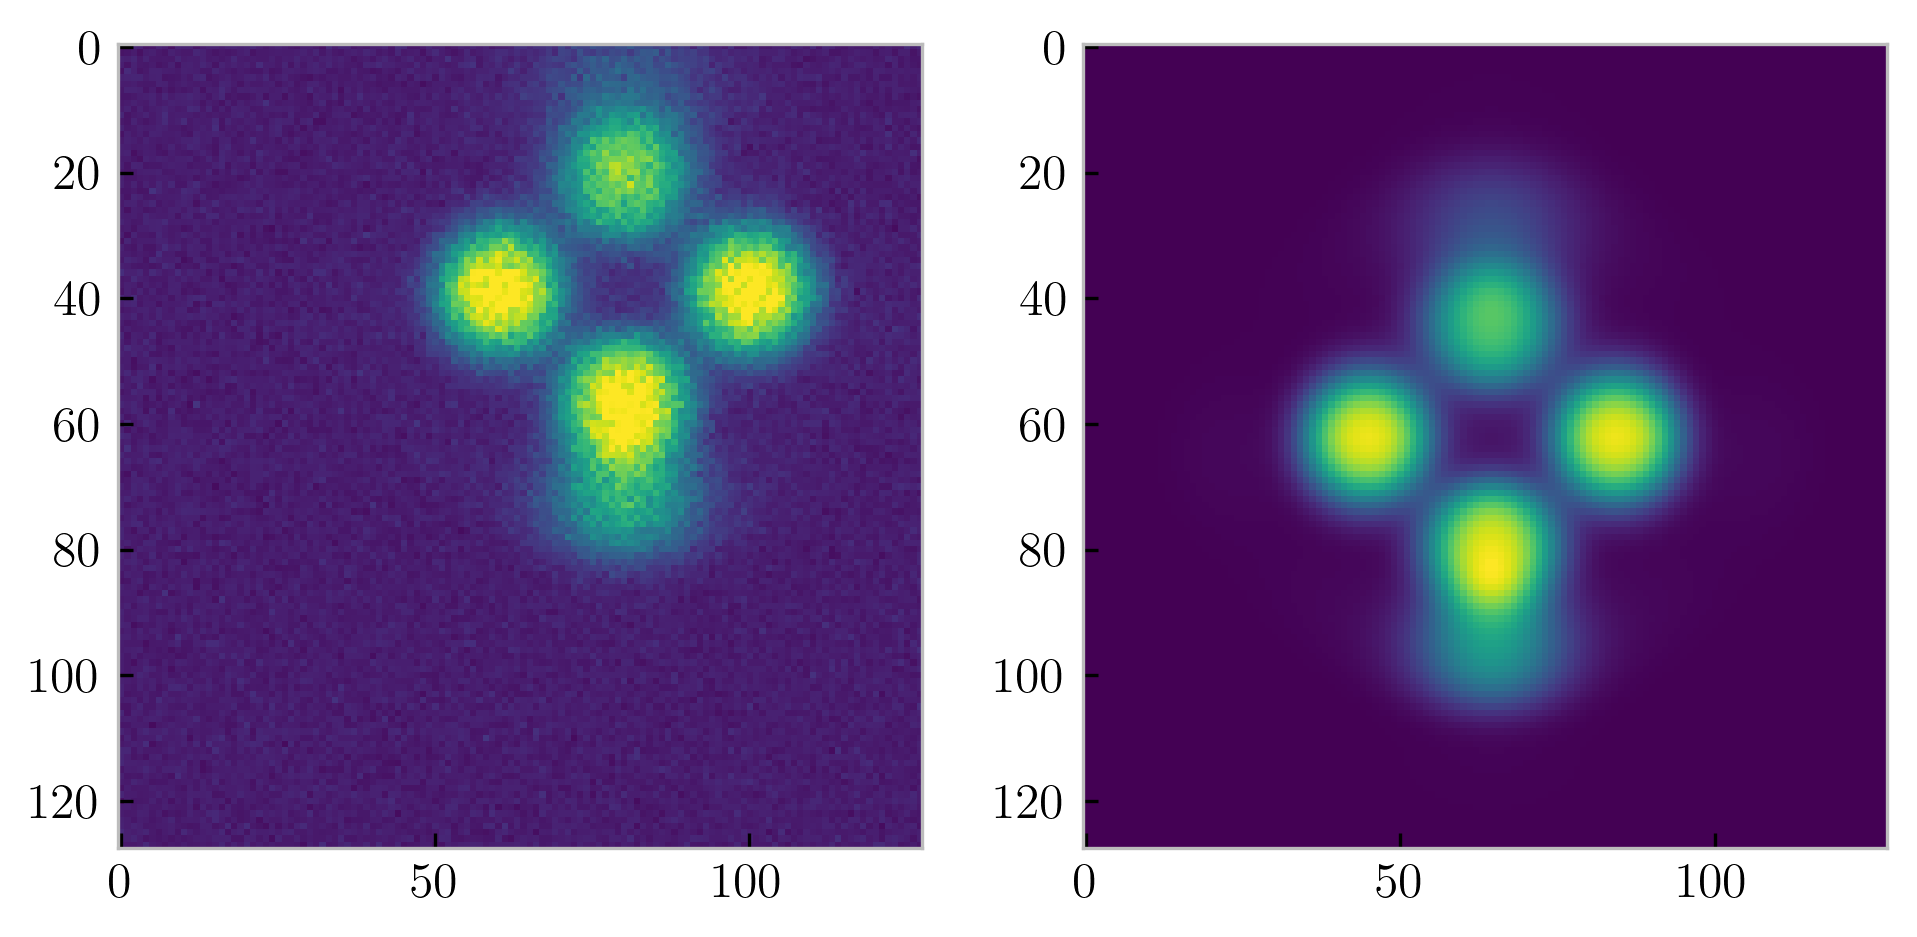

In [26]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(real_img,
              vmin = 0, 
              vmax = 256)
axs[1].imshow(sim_img,
              vmin = 0, 
              vmax = 256)
axs[0].grid(False)
axs[1].grid(False)

Identified offsets: 23.4, -15.6


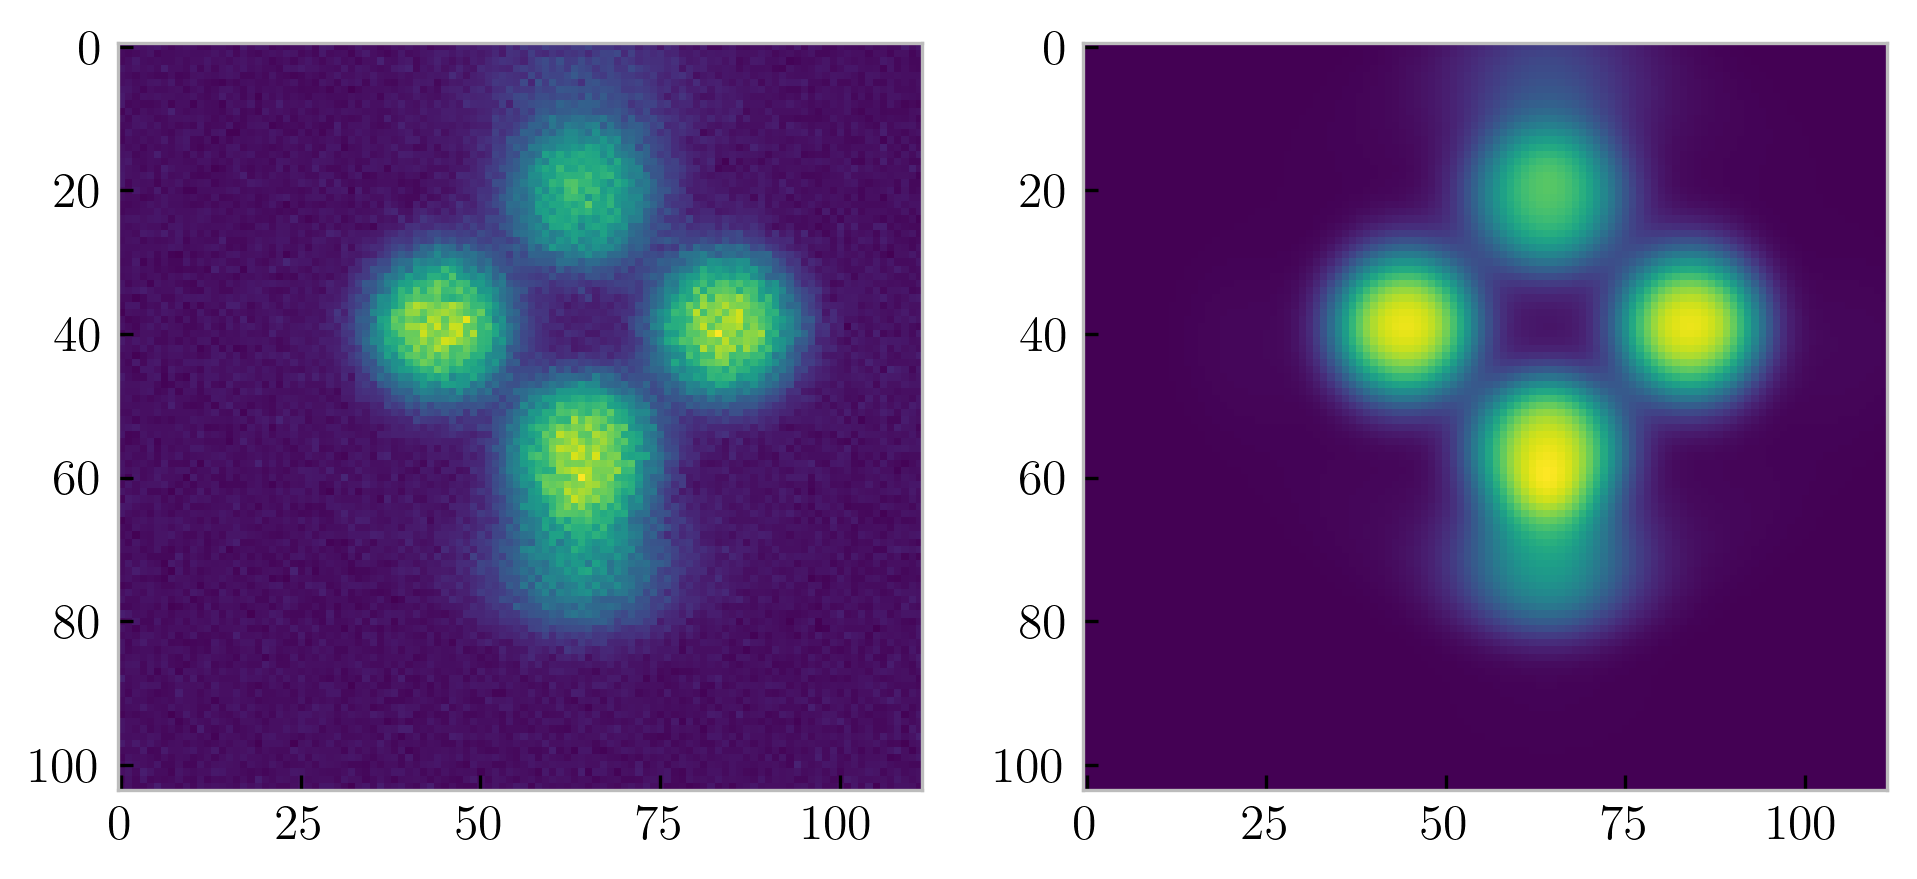

In [27]:
found_offsets, cropped_real_img, cropped_sim_img = alignment_pipeline(real_img, sim_img)

In [28]:
def poisson_dist(x, A, lam):
        return A * (np.power(lam, x) * np.exp(-lam)) / factorial(x)

def fit_poisson(dark_img):
        poisson_data = dark_img.flatten().astype(int)
        counts, bins = np.histogram(poisson_data, bins = np.max(poisson_data) - np.min(poisson_data))
        mu, X = curve_fit(poisson_dist, bins[:-1], counts)
        return ufloat(mu[1], np.sqrt(np.diag(X))[1])

In [29]:
def linear(x, m, b):
    return m * x + b

def scaling_parameters(cropped_sim_img, cropped_real_img):
    mu, X = curve_fit(linear, cropped_sim_img.flatten(), cropped_real_img.flatten())
    return mu, X


In [30]:
def monte_carlo(cropped_sim_img, cropped_real_img, num_samples=1000):
    mu_real, X_real = scaling_parameters(cropped_sim_img, cropped_real_img)

    adjusted_sim_img = linear(cropped_sim_img, *mu_real)
    adjusted_sim_img = np.maximum(adjusted_sim_img, 0)

    real_statistic = np.mean((adjusted_sim_img - cropped_real_img)**2)
    null_statistics = np.zeros(num_samples)
    
    rng = np.random.default_rng()
    for i in range(num_samples):
        #generate fake experiment from fitted null model
        random_sample = rng.poisson(adjusted_sim_img)
        # cmpute null statistic only on overlapping region
        null_statistics[i] = np.mean((random_sample - adjusted_sim_img)**2)

    p_value = (1 + np.sum(null_statistics >= real_statistic)) / (num_samples + 1)

    plt.hist(null_statistics, bins = min(max(int(num_samples/20), 10), 100), color="tab:orange",
             density = True)
    plt.axvline(real_statistic)
    plt.xlabel("MSE statistic")
    plt.ylabel("Probability Density")
    plt.title(f"Monte Carlo null distribution, p = {p_value:.3g}")
    plt.show()

    return real_statistic, null_statistics, p_value

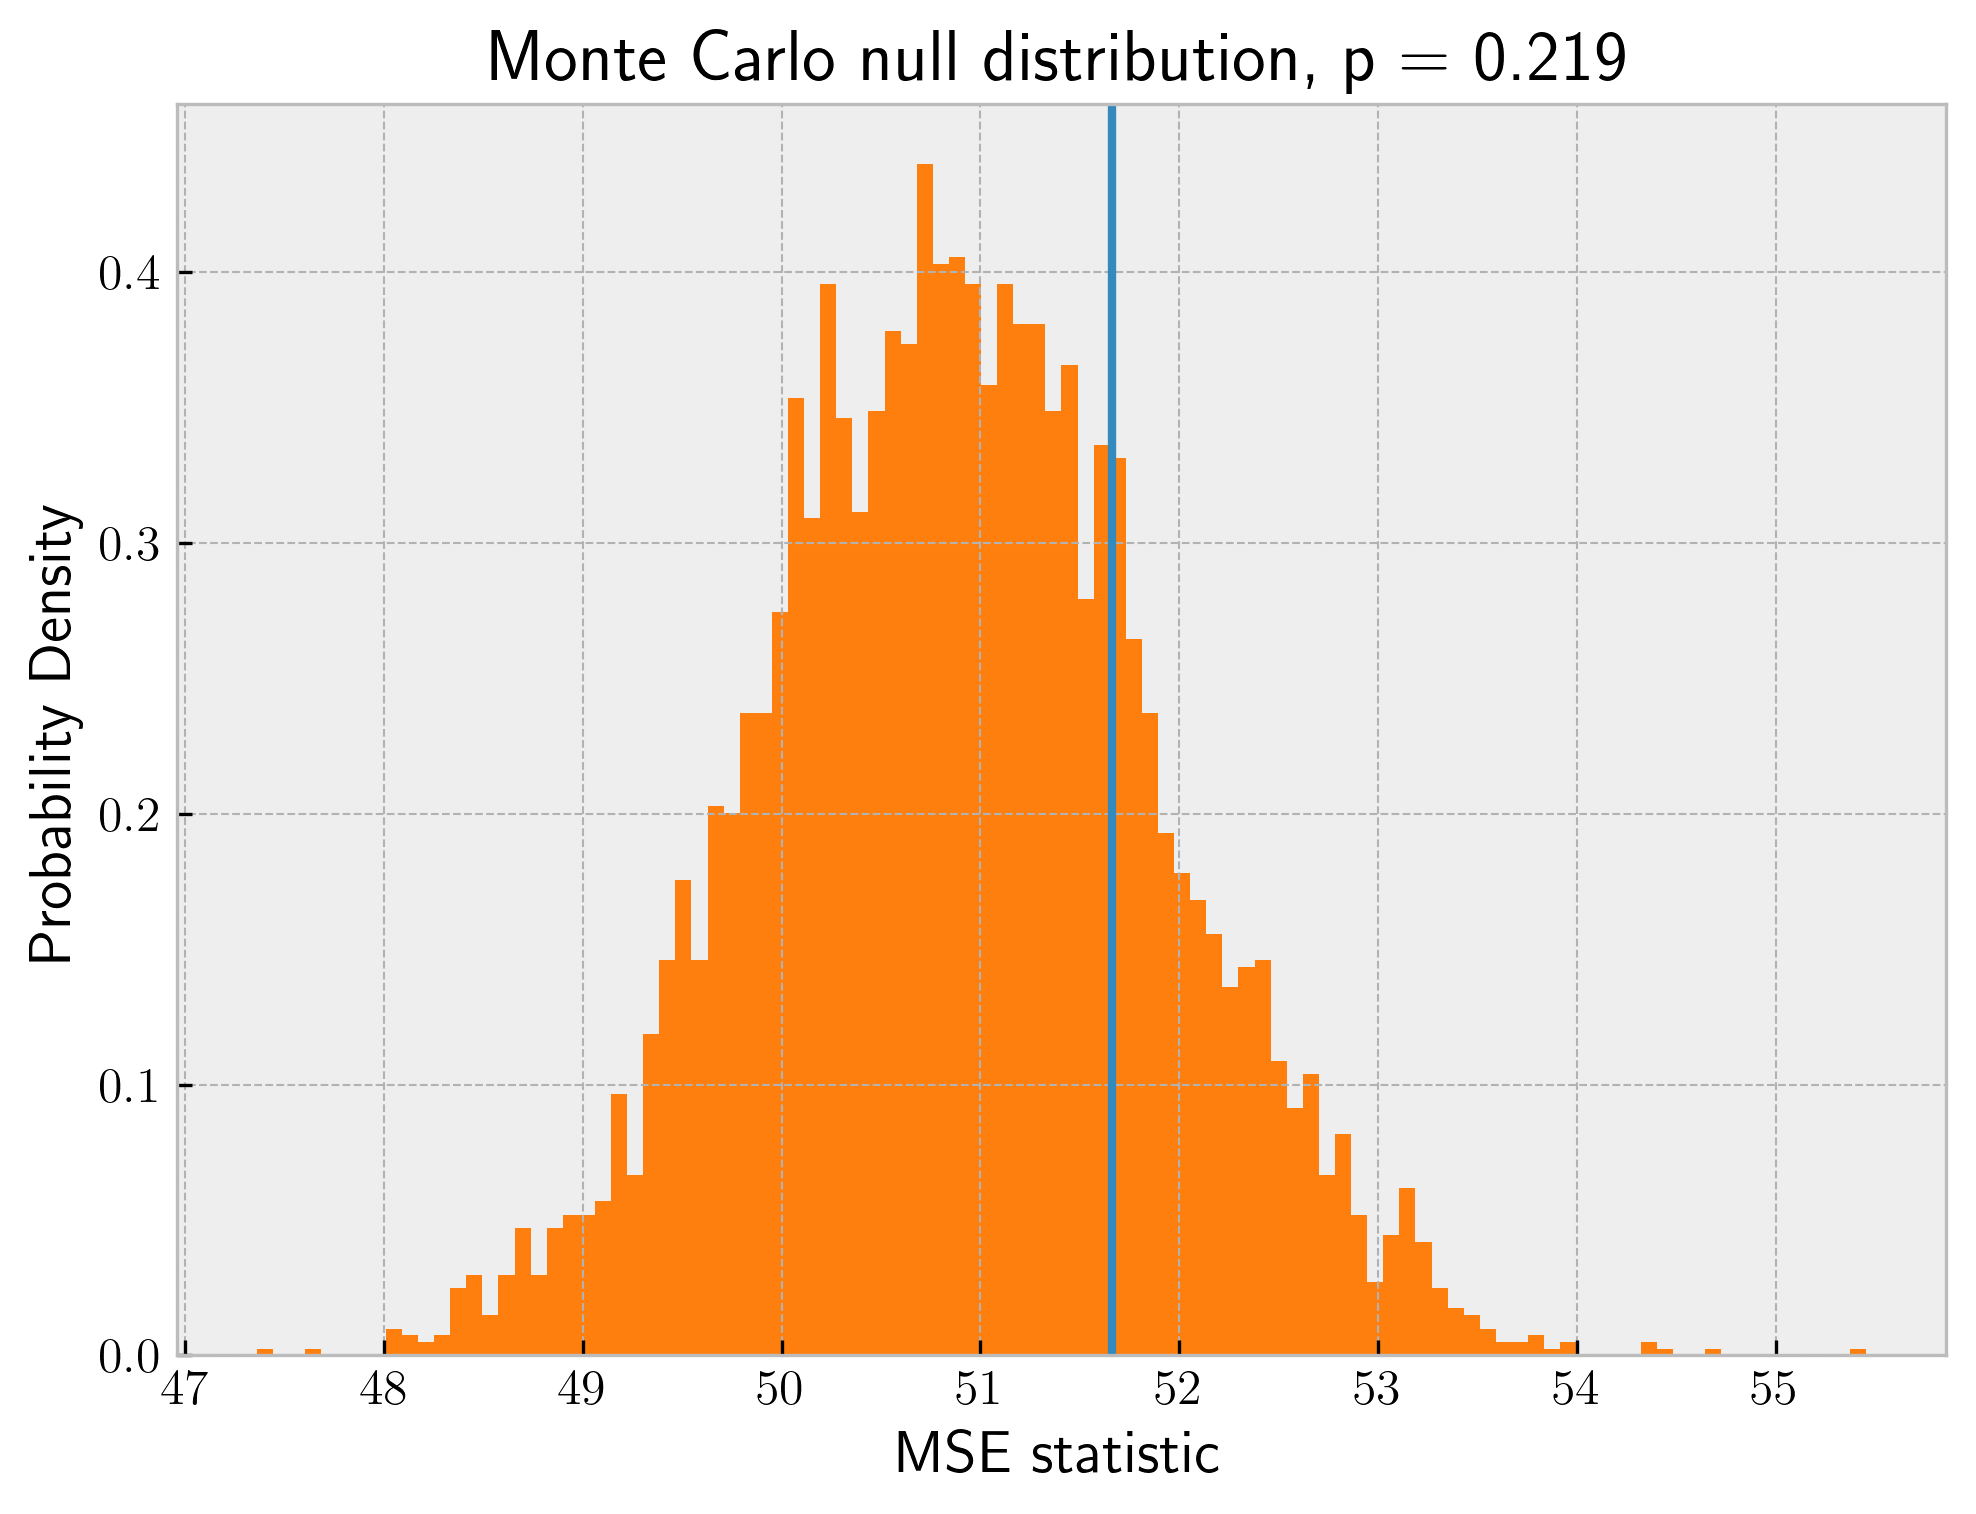

In [31]:
real_statistic, null_statistics, p_value = monte_carlo(cropped_sim_img, cropped_real_img, 5000)